In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal

from wattson.models.power_supply import Battery
from wattson.models.database import Database

%matplotlib widget

In [2]:
# battery = Battery()
database = Database()

In [3]:
df = database.get_data()

Using Dask to collect the data from the MySQL database.


In [4]:
df.dropna(inplace=True)

In [5]:
df["time"] = df['time'].astype("float64")

In [6]:
df['cpu_temp'] = df['cpu_temp'] / 10**3 # Converting milli-Fahrenheit to Fahrenheit.
df['wifi_temp'] = df['wifi_temp'] / 10**3 # Converting milli-Fahrenheit to Fahrenheit.
df["time"] = df["time"] / 10**3 # Converting from milliseconds to seconds.
df['energy'] = df['energy'] / 10**9 # Converting from nano-Joules to Joules.
df['voltage'] = df['voltage'] / 10**6 # Converting from micro-Volts to Volts.

In [7]:
df

,time,voltage,energy,power,capacity,cpu_temp,wifi_temp
id,,,,,,,
1,1.753319e+09,8.065,0.03253,0.0,100,43.0,40.00
2,1.753319e+09,8.065,0.03253,0.0,100,42.0,42.00
3,1.753319e+09,8.065,0.03253,0.0,100,43.0,39.00
4,1.753319e+09,8.065,0.03253,0.0,100,43.0,41.00
5,1.753319e+09,8.065,0.03253,0.0,100,42.0,39.00
...,...,...,...,...,...,...,...
3189298,1.757131e+09,8.007,0.03094,0.0,100,44.0,45.05
3189299,1.757131e+09,8.007,0.03094,0.0,100,45.0,45.05
3189300,1.757131e+09,8.007,0.03094,0.0,100,45.0,45.05


In [8]:
df.set_index("time", inplace=True)

In [9]:
energy = df['energy']
voltage = df['voltage']
power = df['power']
wifi_temp = df['wifi_temp']
cpu_temp = df['cpu_temp']
capacity = df["capacity"]

In [10]:
charging = power > 0
discharging = ~charging

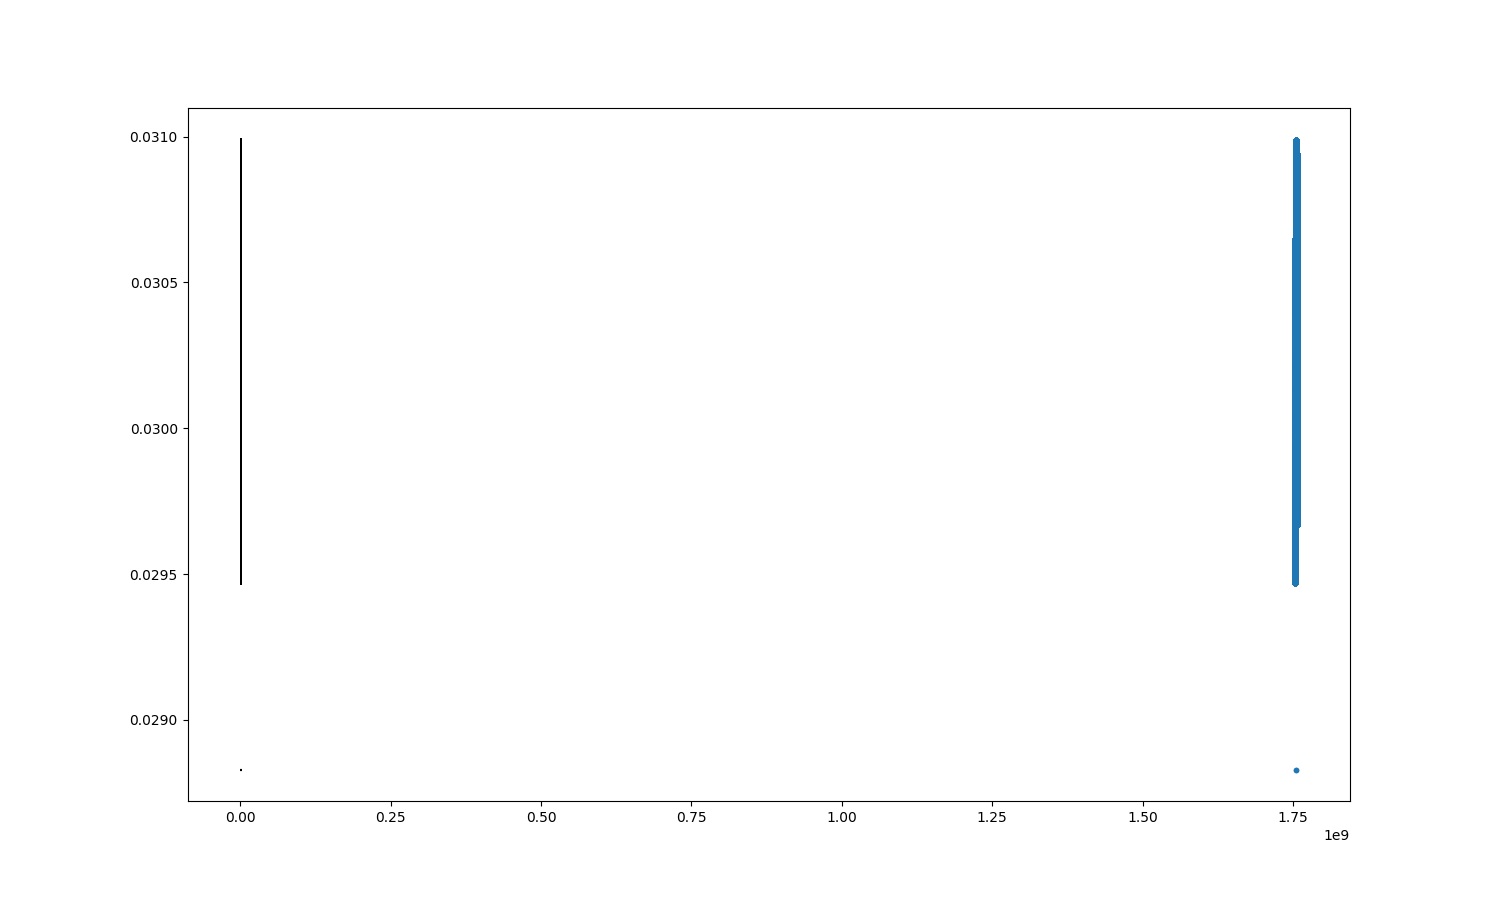

In [ ]:
time_mask = df.index > 1.753e9 + 490000
energy_time_slice = energy[time_mask][discharging]
f, axs = plt.subplots(figsize=(15,9))
axs.plot(energy_time_slice, '.')
axs.hlines(energy_time_slice, 0, len(energy_time_slice), color='k', linestyles='--')                                                                                                          

In [ ]:
plt.figure(figsize=(15,9))
plt.hist(energy[discharging], bins='fd')

In [ ]:
# TODO: Make object to hold and handle chemical reactions, thermodynamic quantities, and perform thermodynamic calculations.